In [2]:
!nvidia-smi


Thu Dec  4 04:35:34 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.8 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO
import os
from IPython.display import display, Image, clear_output
clear_output()
!yolo checks

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.1/112.6 GB disk)

OS                     Linux-6.6.105+-x86_64-with-glibc2.35
Environment            Colab
Python                 3.12.12
Install                pip
Path                   /usr/local/lib/python3.12/dist-packages/ultralytics
RAM                    12.67 GB
Disk                   38.1/112.6 GB
CPU                    Intel Xeon CPU @ 2.00GHz
CPU count              2
GPU                    Tesla T4, 15095MiB
GPU count              1
CUDA                   12.6

numpy                  ✅ 2.0.2>=1.23.0
matplotlib             ✅ 3.10.0>=3.3.0
opencv-python          ✅ 4.12.0.88>=4.6.0
pillow                 ✅ 11.3.0>=7.1.2
pyyaml                 ✅ 6.0.3>=5.3.1
requests               ✅ 2.32.4>=2.23.0
scipy                  ✅ 1.16.3>=1.4.1
torch                  ✅ 2.9.0+cu126>=1.8.0
torch                  ✅ 2.9.0+cu126!=2.4.0,>=1.8.0; sys_platform == "win32"


In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="hnrP4b2ZPs2NVzmswPfi")
project = rf.workspace("projects-erksv").project("refinement-ua-detrac-2")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 119.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Refinement-UA-DETRAC-2-1 in yolov8:: 100%|██████████| 28268/28268 [00:07<00:00, 3907.78it/s]


In [6]:
!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=30 imgsz=640 batch=16 workers=8

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Refinement-UA-DETRAC-2-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plo

In [7]:
from google.colab import files

# Path to your trained model
model_path = '/content/runs/detect/train/weights/best.pt'

# Download to your local machine
files.download(model_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

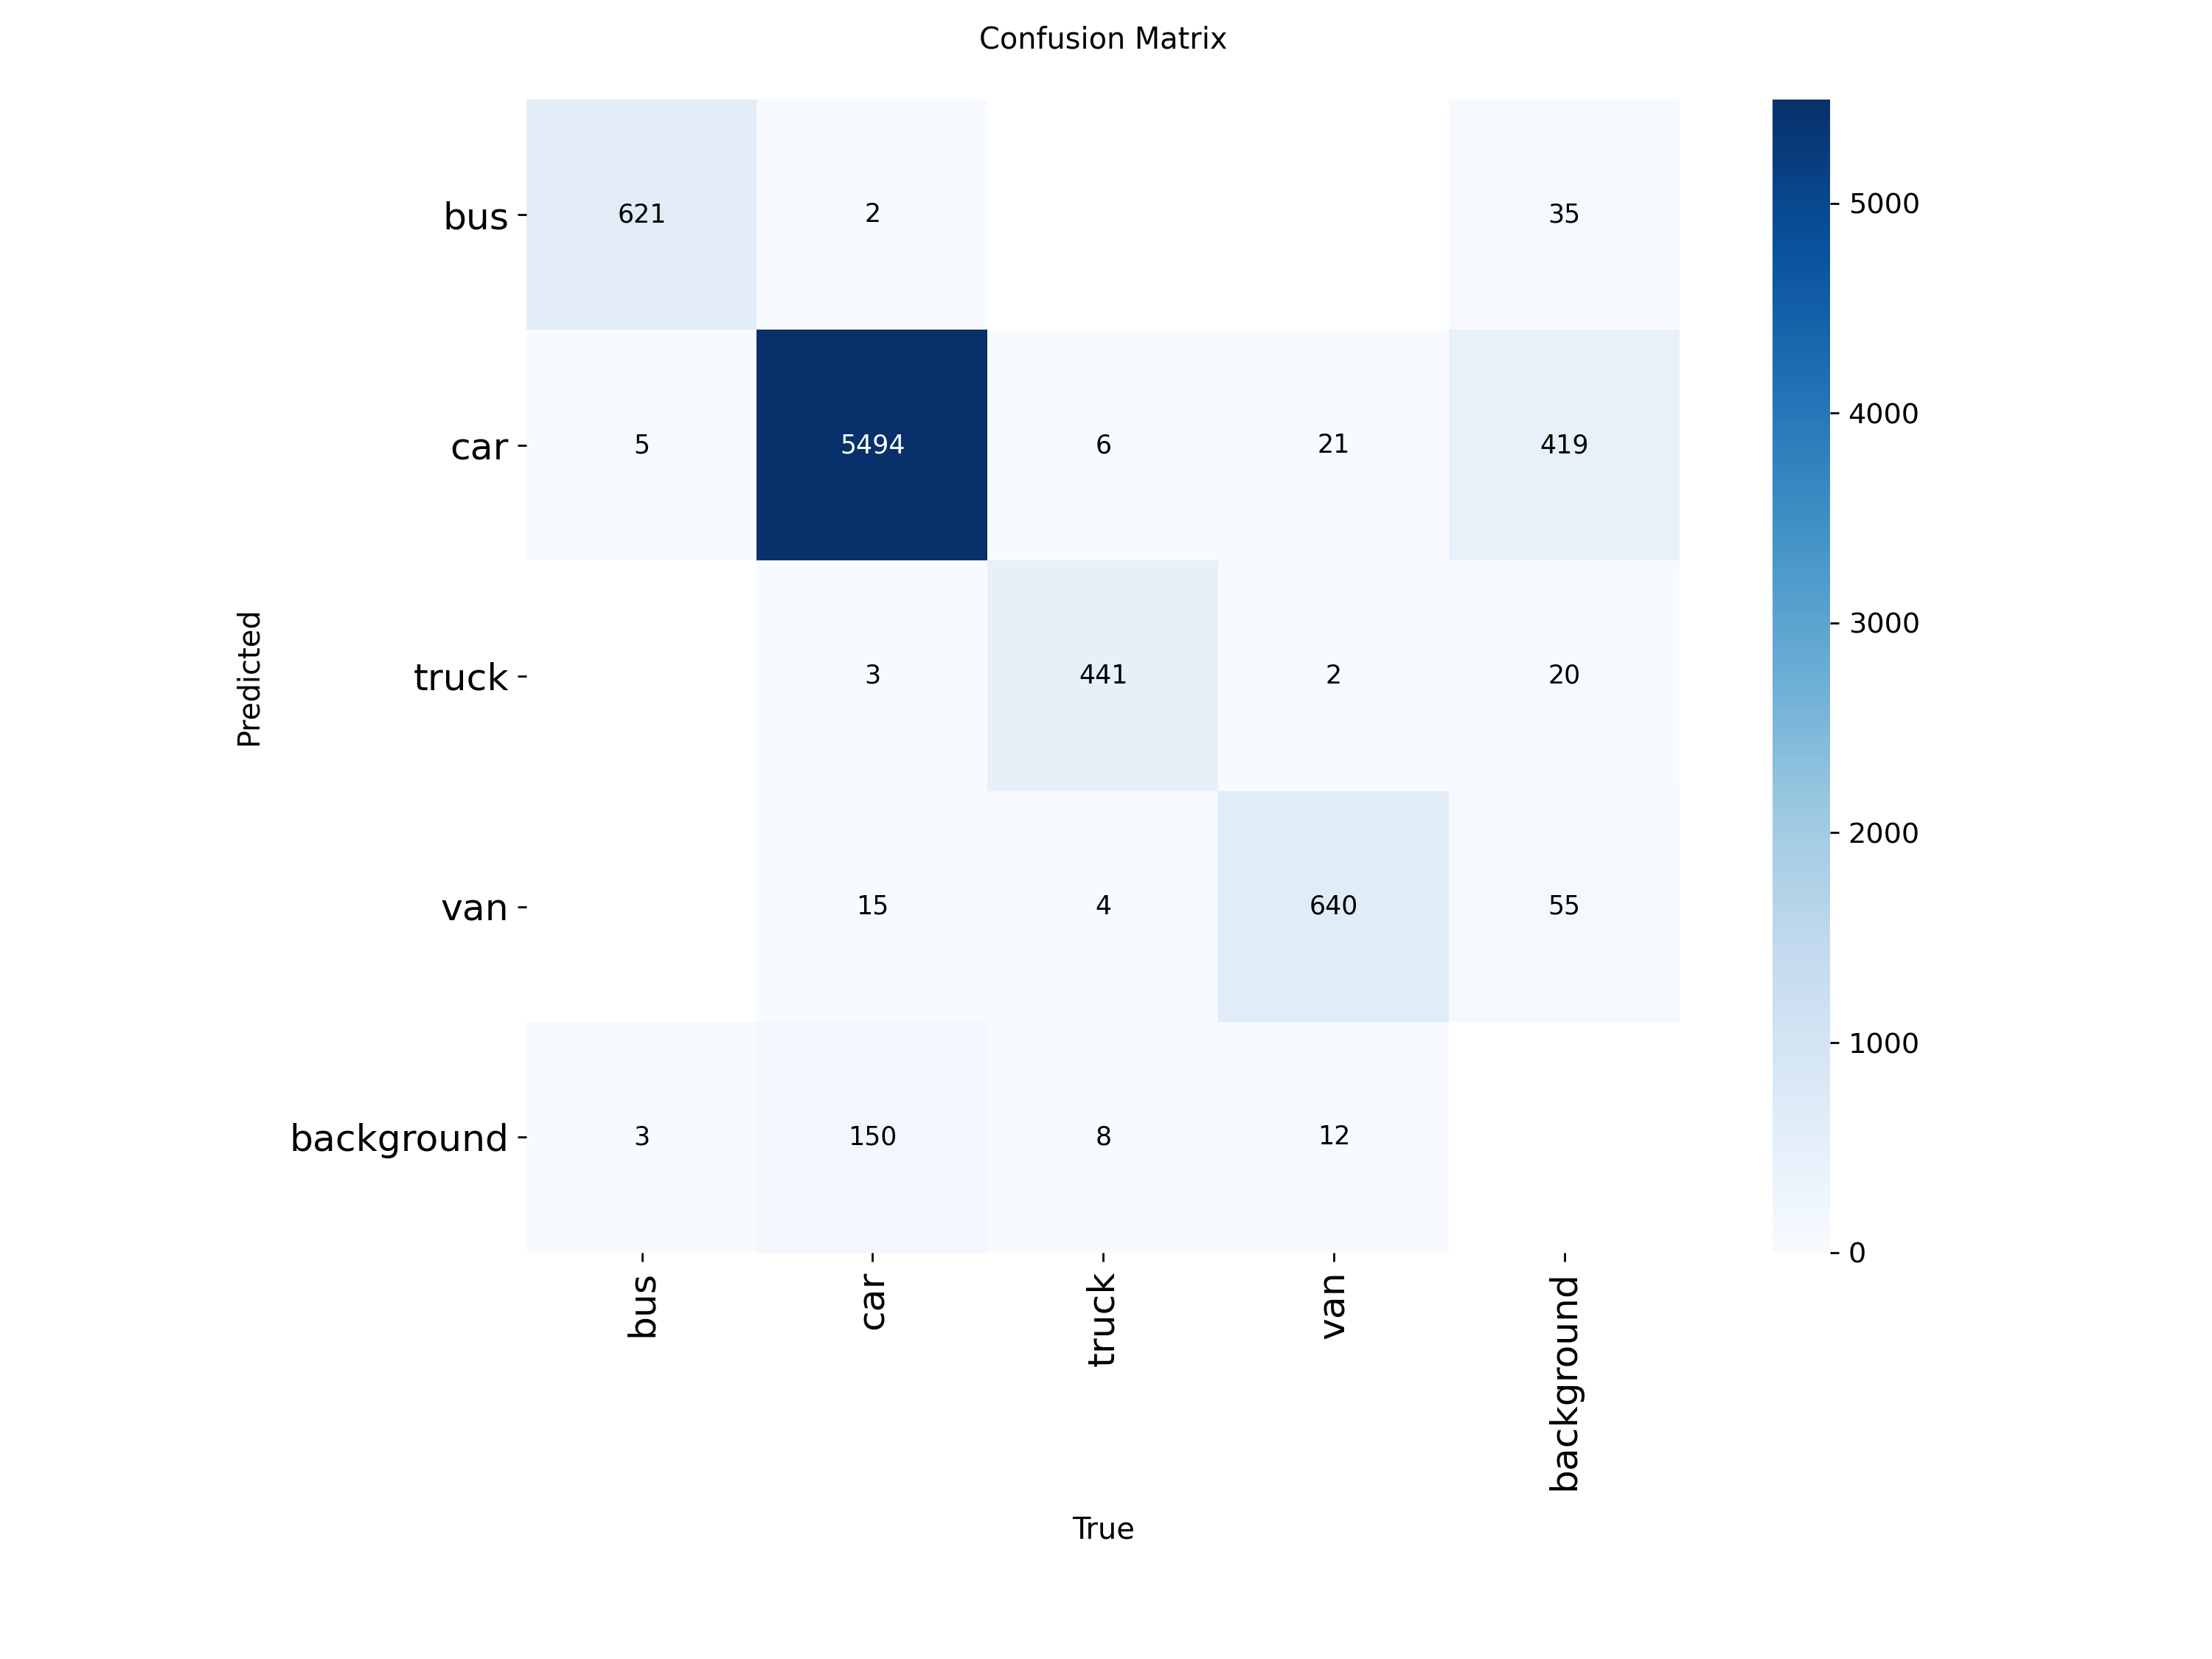

In [8]:
Image(filename=f'/content/runs/detect/train/confusion_matrix.png', width=600)

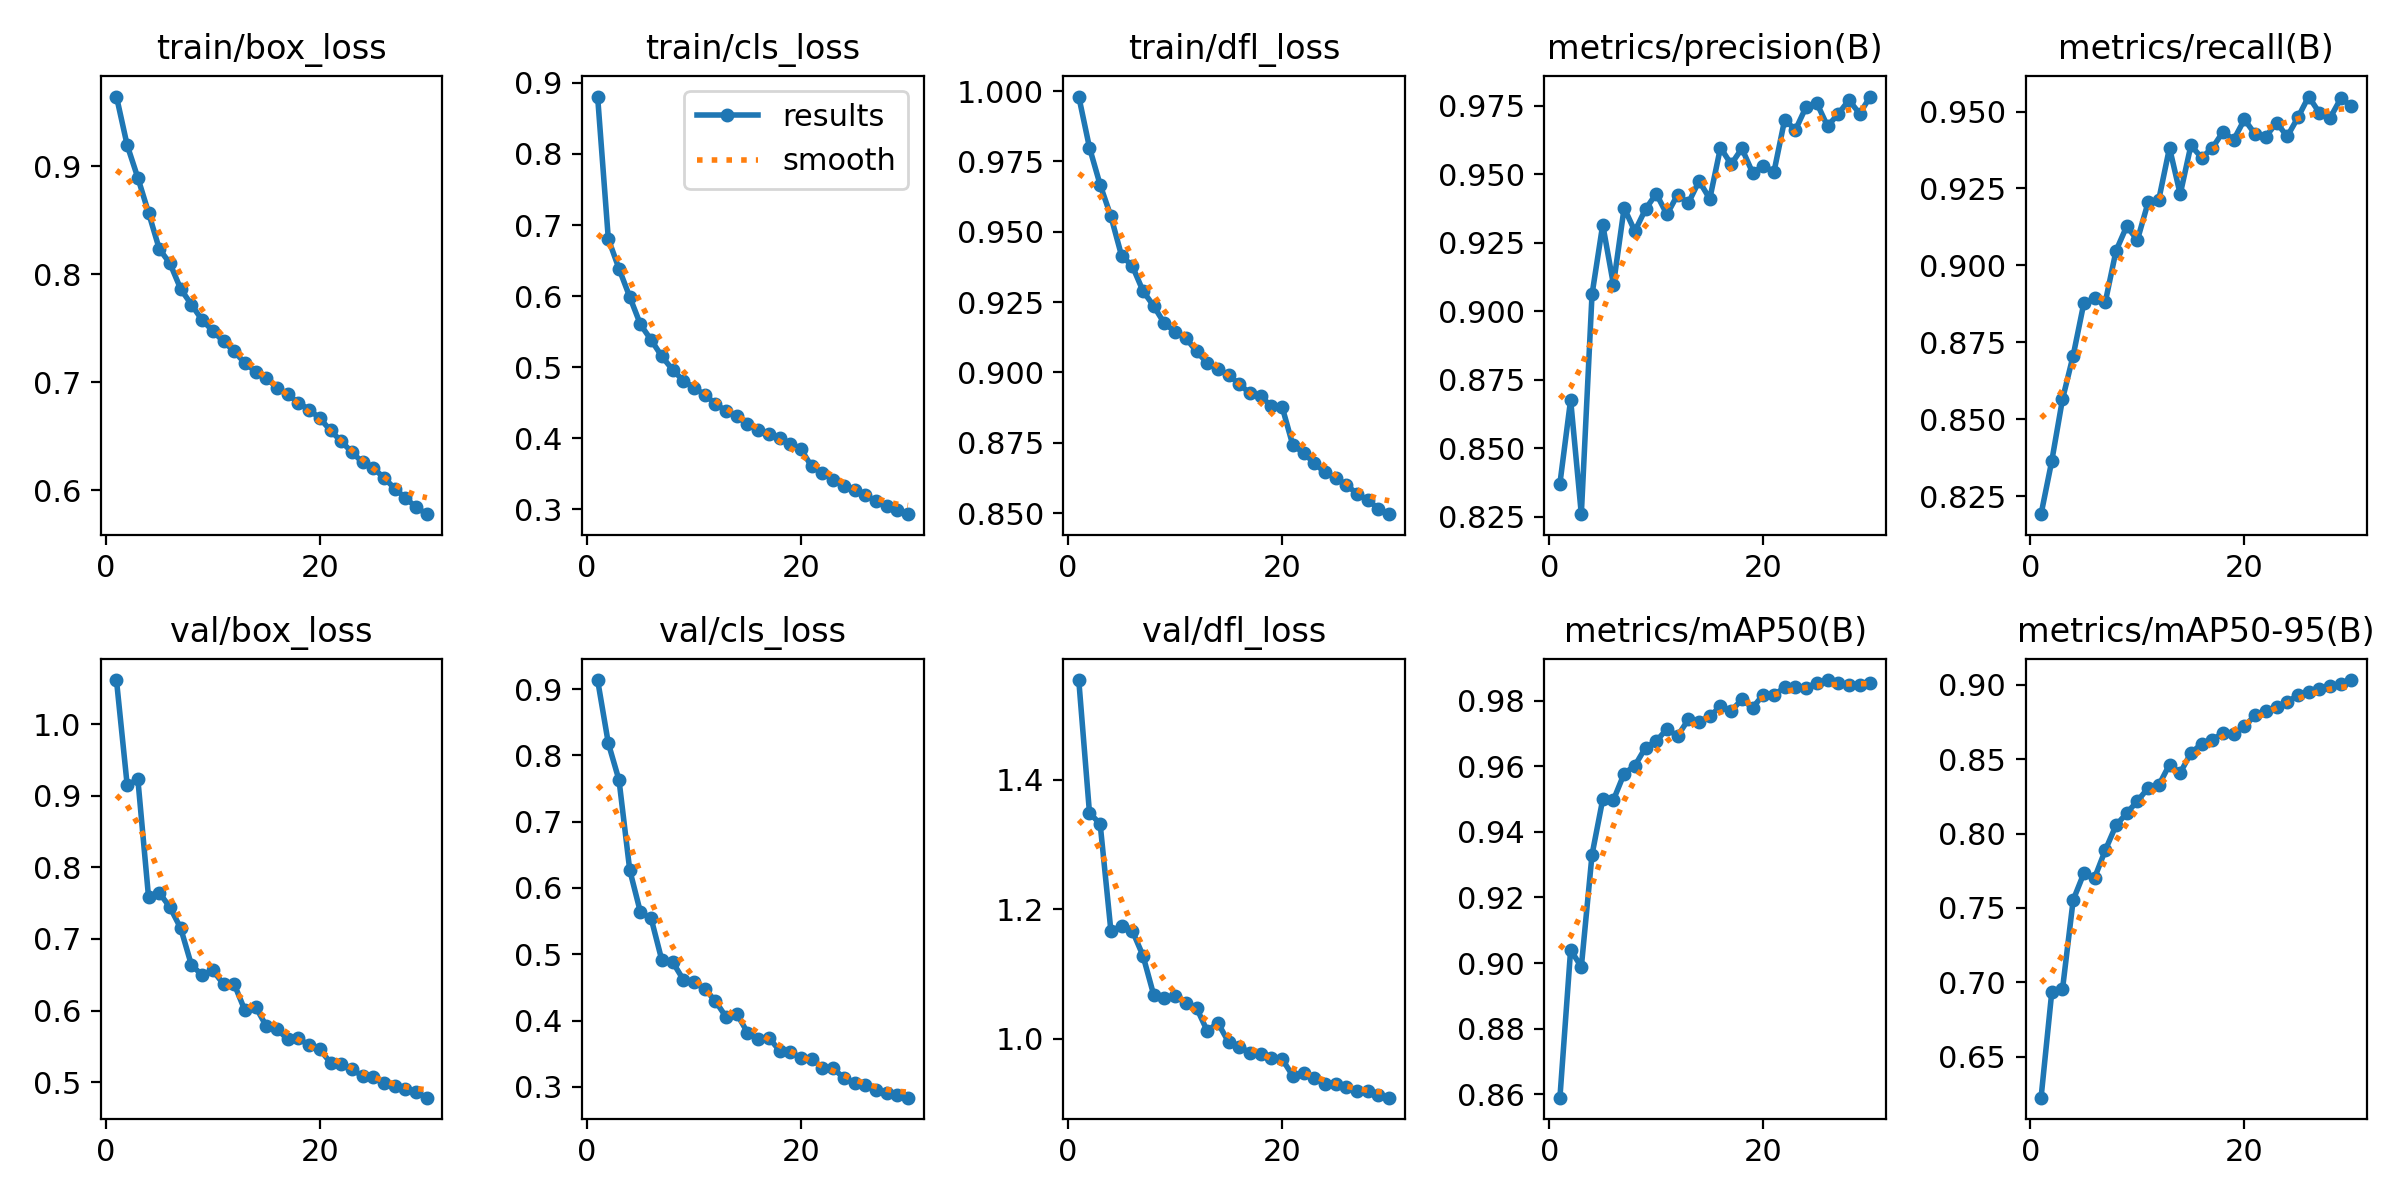

In [9]:
Image(filename=f'/content/runs/detect/train/results.png', width=600)

In [10]:
!yolo task=detect mode=val model=/content/runs/detect/train/weights/best.pt data=/content/Refinement-UA-DETRAC-2-1/data.yaml

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1699.1±512.1 MB/s, size: 67.4 KB)
val: Scanning /content/Refinement-UA-DETRAC-2-1/valid/labels.cache... 1413 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1413/1413 15.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 89/89 5.3it/s 16.8s
                   all       1413       7427      0.978      0.952      0.985      0.904
                   bus        300        629      0.981      0.978      0.994      0.936
                   car        754       5664      0.974      0.939      0.988      0.855
                 truck        440        459      0.991      0.959       0.98      0.918
                   van        562        675      0.966      0.933      0.979      0.907
Speed: 0.9ms preprocess, 6

In [11]:
!yolo task=detect mode=predict model=/content/runs/detect/train/weights/best.pt conf=0.5 source=/content/Refinement-UA-DETRAC-2-1/test/images save=True

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs

image 1/1413 /content/Refinement-UA-DETRAC-2-1/test/images/-3163ca687f_jpg.rf.ea68ca3771568723f13cf2b3ef624b98.jpg: 640x640 1 truck, 16.3ms
image 2/1413 /content/Refinement-UA-DETRAC-2-1/test/images/-_57_jpg.rf.4a4da0627a8a1d2ed2b740e4e3157a95.jpg: 640x640 1 truck, 16.3ms
image 3/1413 /content/Refinement-UA-DETRAC-2-1/test/images/0000147617-e4eb190337827f8bbbcc9317d_jpg.rf.4a934cc4488d14c971293d8038ef2640.jpg: 640x640 1 truck, 16.2ms
image 4/1413 /content/Refinement-UA-DETRAC-2-1/test/images/0000161190-eff4a7d6440628a6ed58e9d9a_jpg.rf.7c48c79a39ed27fb204abd45460e321d.jpg: 640x640 1 truck, 16.2ms
image 5/1413 /content/Refinement-UA-DETRAC-2-1/test/images/013877-1-lg_jpg.rf.8233cad3ffefeced4845759cc7c3c369.jpg: 640x640 1 truck, 16.2ms
image 6/1413 /content/Refinement-UA-DETRAC-2-1/test/images/0ed5b30d578ecfa7a65f-1296x954_jp

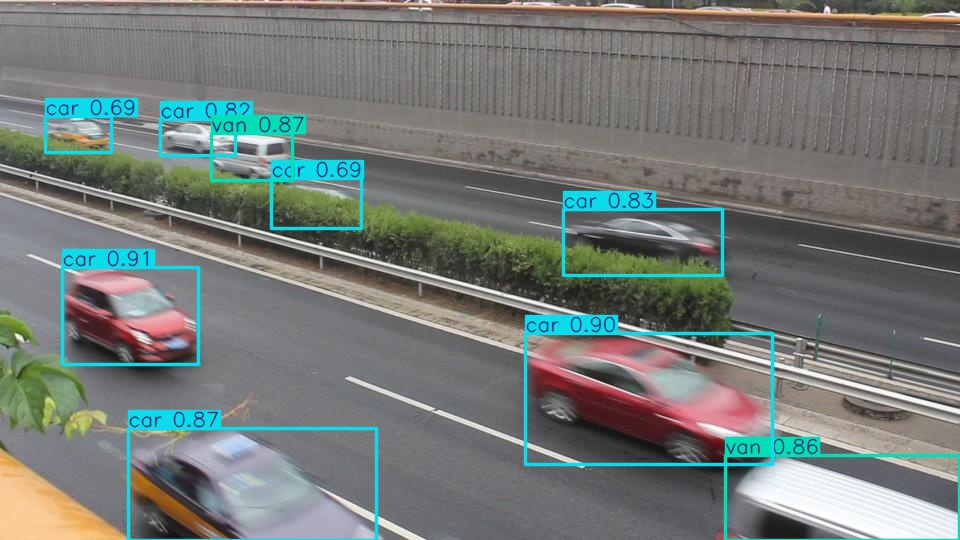

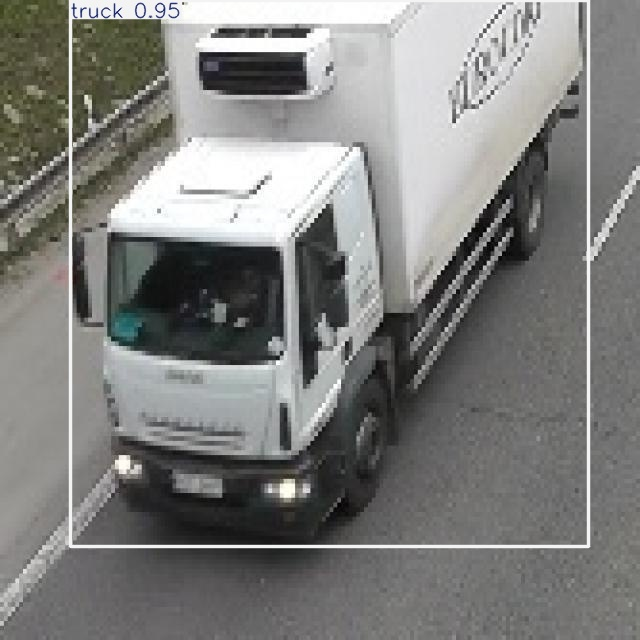

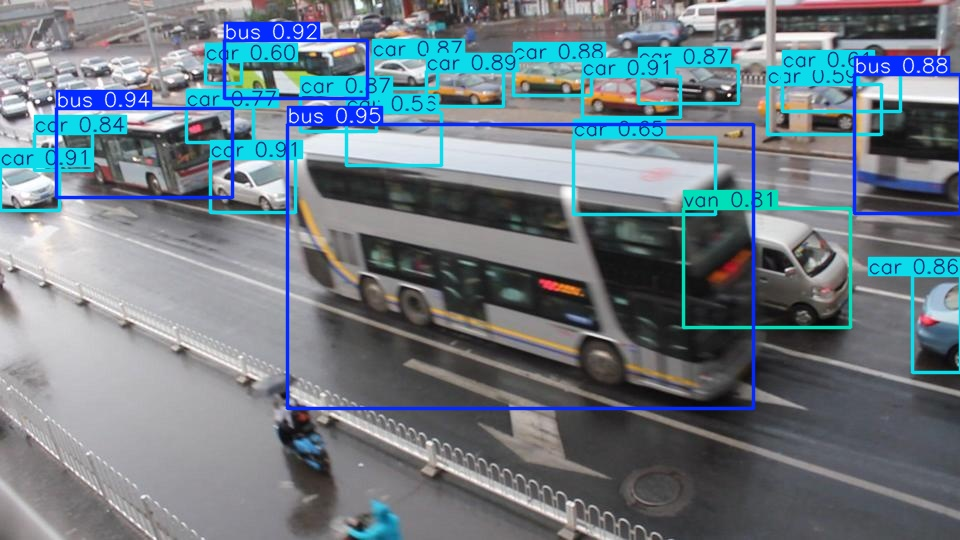

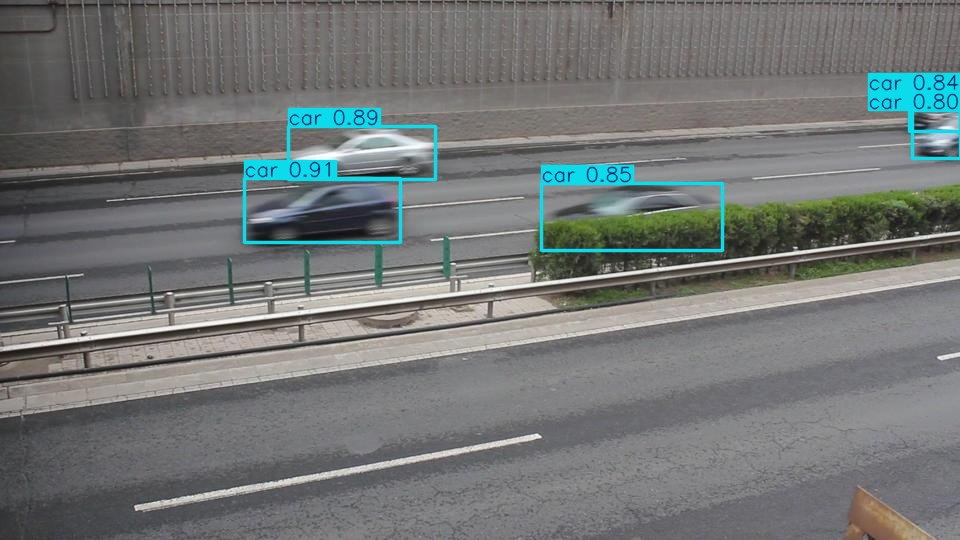

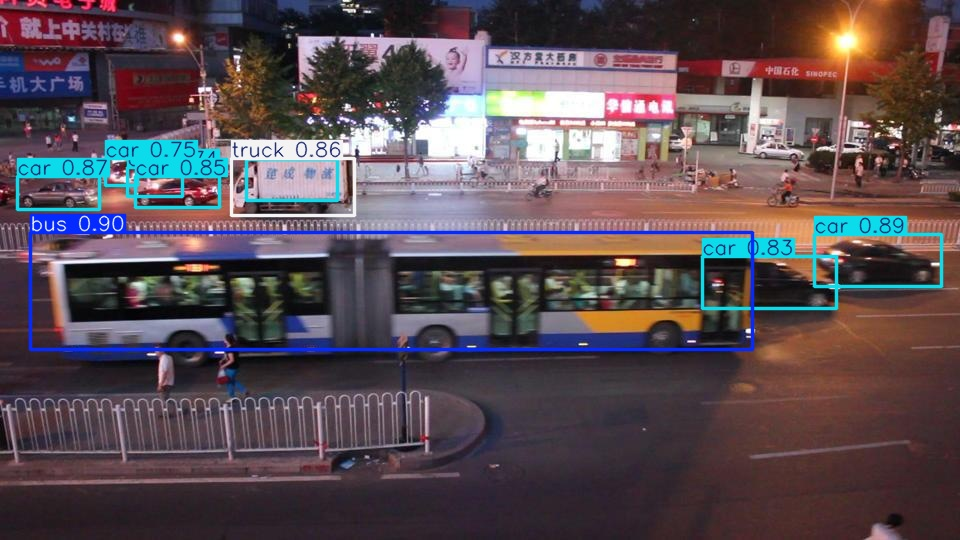

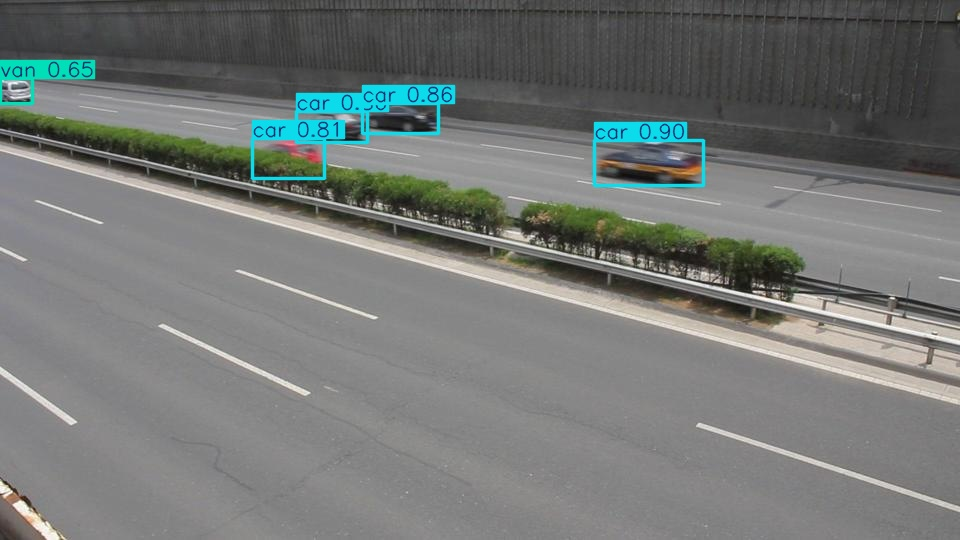

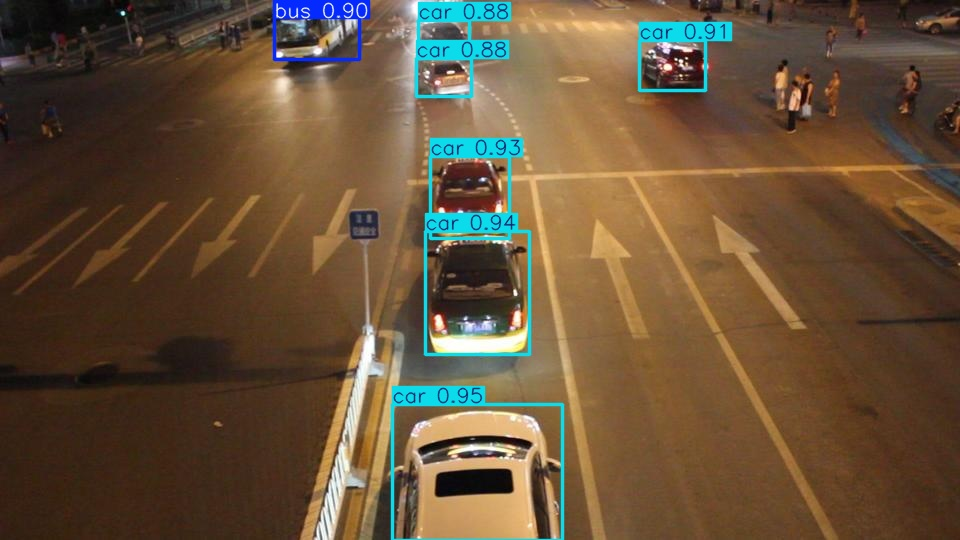

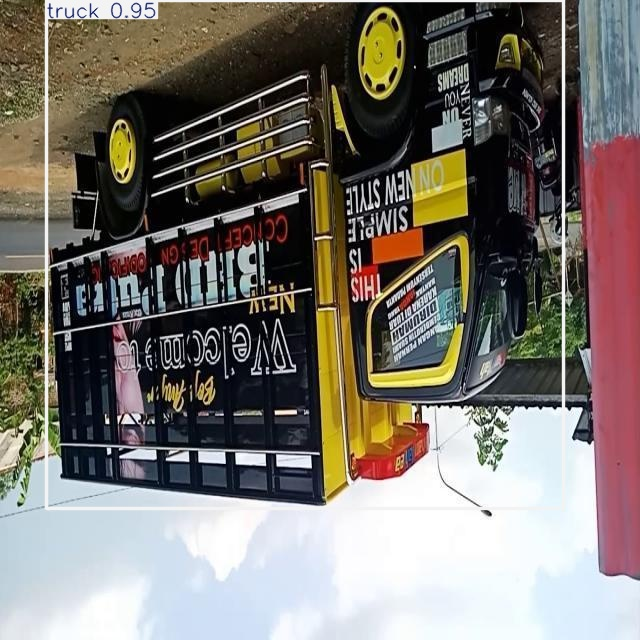

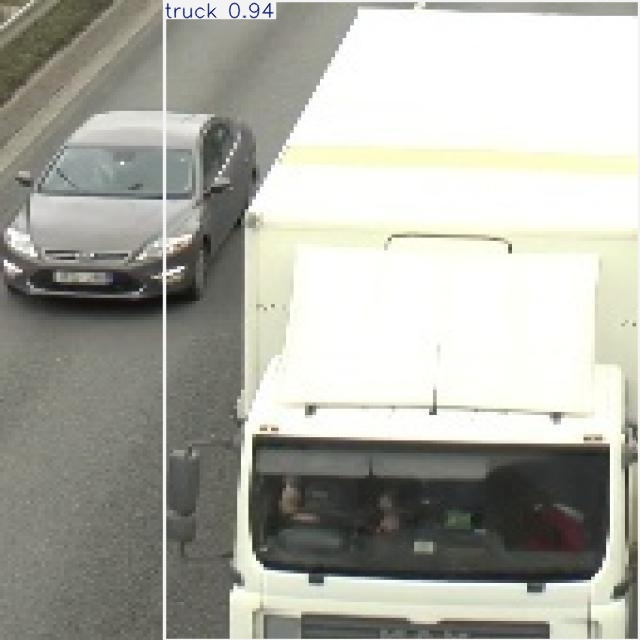

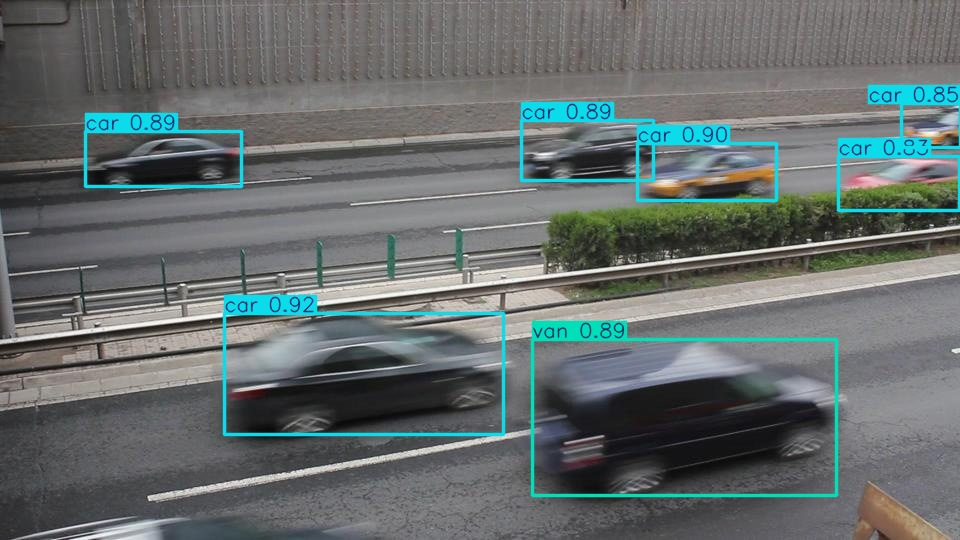

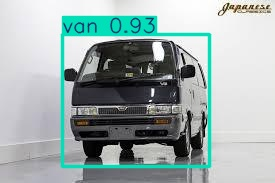

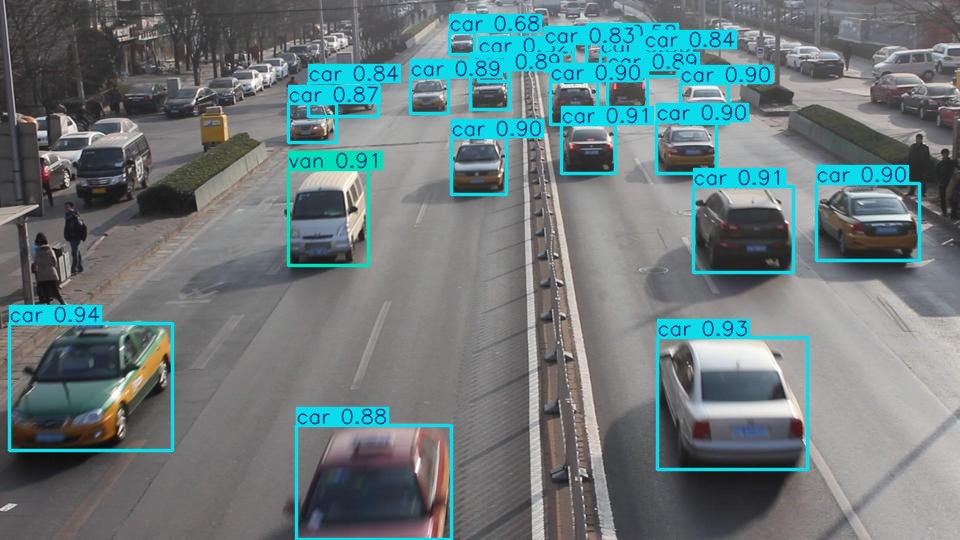

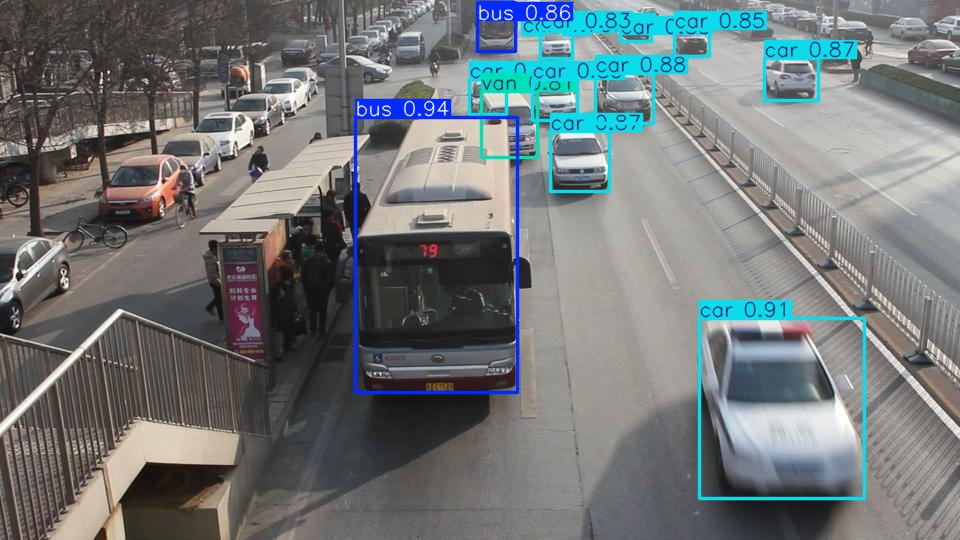

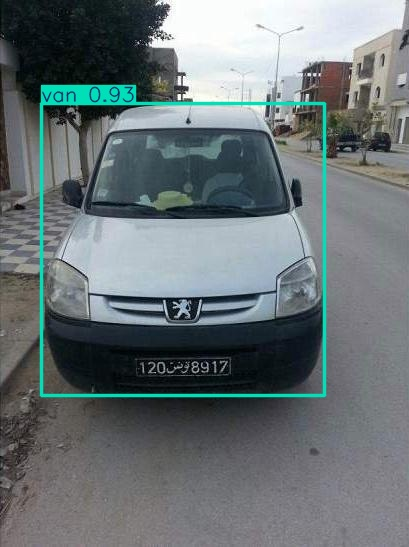

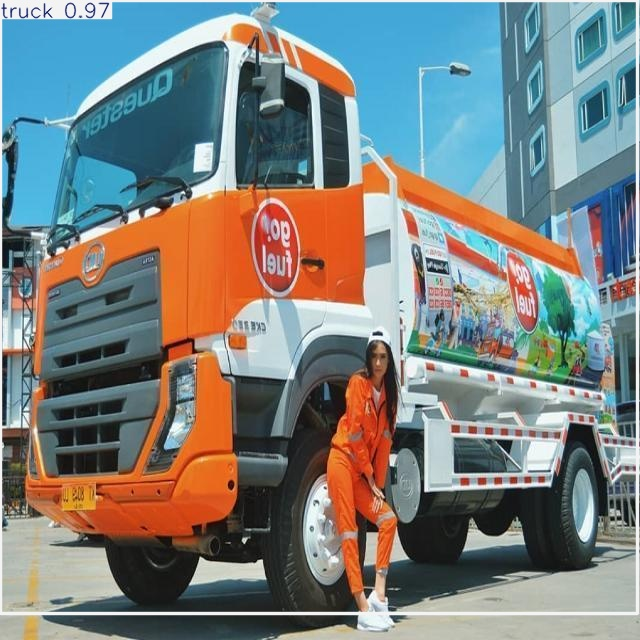

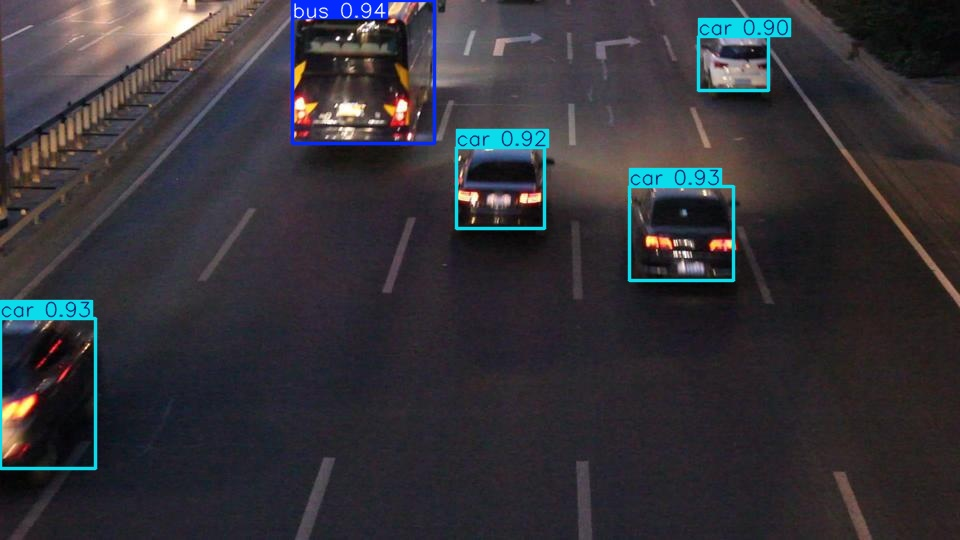

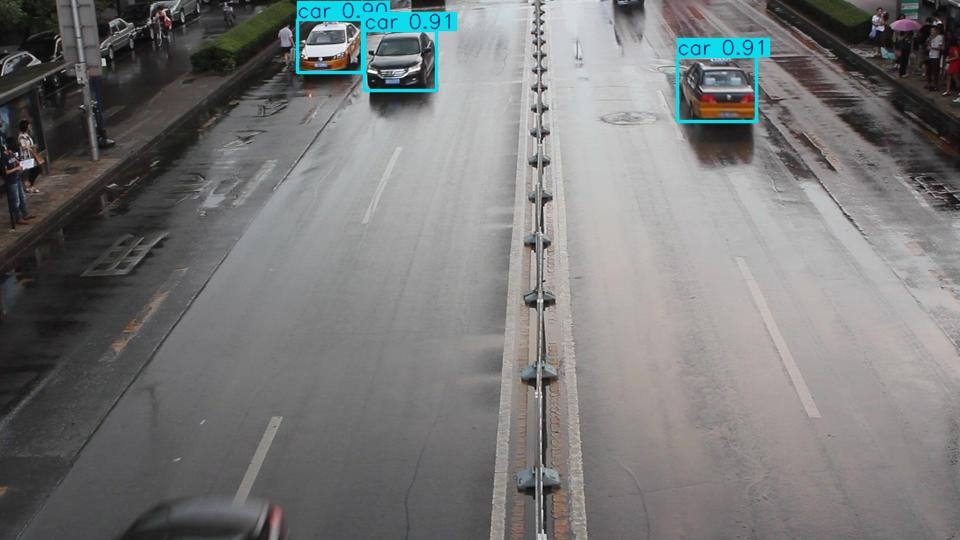

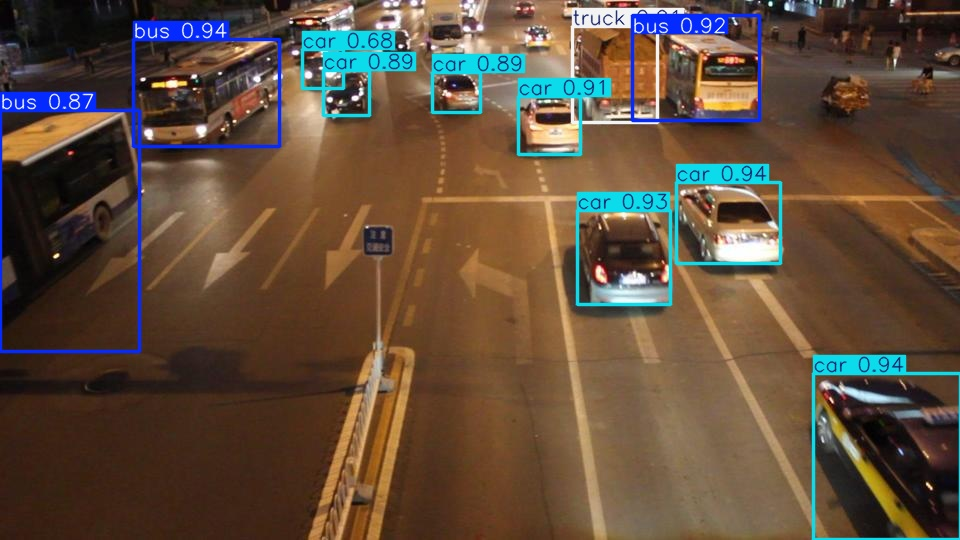

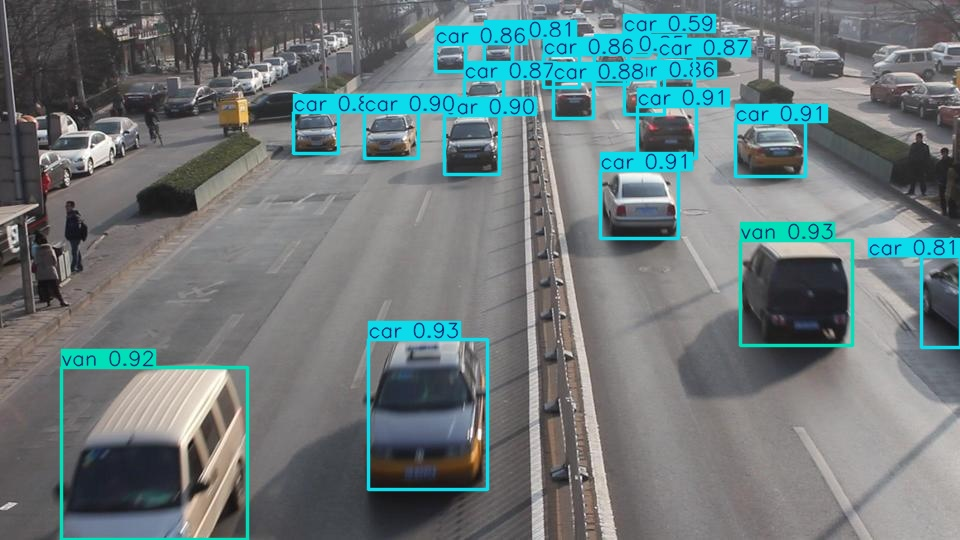

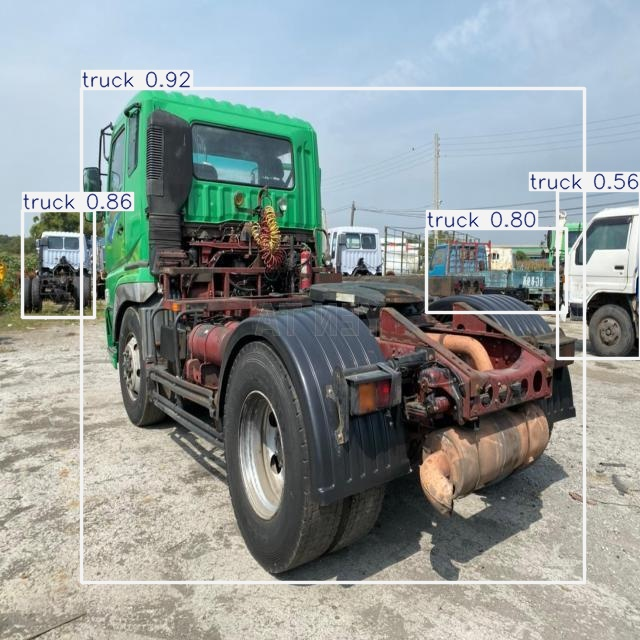

In [12]:
import glob
from IPython.display import Image, display

# Get all jpg images in the latest predict folder
image_paths = glob.glob('/content/runs/detect/predict/*.jpg')[:20]  # first 20 images

# Display them
for img_path in image_paths:
    display(Image(filename=img_path, width=600))

In [ ]:
import os

save_path = '/content/drive/MyDrive/Final_YOLO_Vehicules'
os.makedirs(save_path, exist_ok=True)

In [ ]:
# Copy best.pt model
!cp /content/runs/detect/train/weights/best.pt /content/drive/MyDrive/Final_YOLO_Vehicules/

# Copy runs
!cp -r /content/runs/detect/* /content/drive/MyDrive/Final_YOLO_Vehicules/